<a href="https://colab.research.google.com/github/mehaklaha/Machine-Learning-LAB-Repo/blob/main/Lab1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("joebeachcapital/cirrhosis-patient-survival-prediction")

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 11.0k/11.0k [00:00<00:00, 10.1MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/joebeachcapital/cirrhosis-patient-survival-prediction/versions/1
/root/.cache/kagglehub/datasets/joebeachcapital/cirrhosis-patient-survival-prediction/versions/1/cirrhosis.csv


In [4]:
file_path = os.path.join(path, "cirrhosis.csv")  # adjust if needed

df = pd.read_csv(file_path)

df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for col in df.columns:
    print(col)

Dataset Shape: (418, 20)

Column Names:
ID
N_Days
Status
Drug
Age
Sex
Ascites
Hepatomegaly
Spiders
Edema
Bilirubin
Cholesterol
Albumin
Copper
Alk_Phos
SGOT
Tryglicerides
Platelets
Prothrombin
Stage


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [7]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64


In [8]:
df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
10%,42.700000,606.800000,13283.700000,0.600000,213.600000,2.967000,24.000000,663.000000,60.450000,63.100000,138.200000,9.800000,2.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
90%,376.300000,3524.200000,23487.000000,8.030000,560.800000,4.010000,208.100000,3826.400000,196.465000,195.000000,386.200000,12.000000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [9]:
df_clean = df.select_dtypes(include=[np.number])

df_clean.head()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


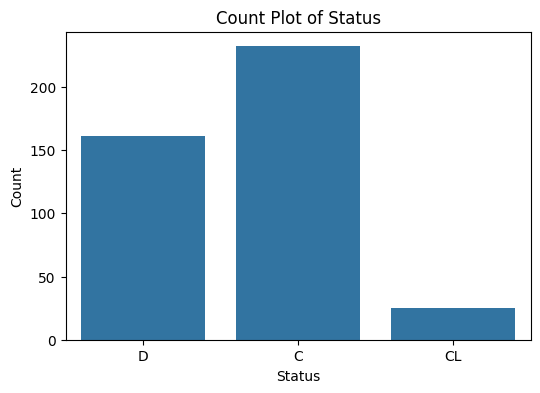

In [12]:
plt.figure(figsize=(6,4))

target_col = 'Status'  # change if needed

sns.countplot(data=df, x=target_col)

plt.title(f'Count Plot of {target_col}')
plt.xlabel(target_col)
plt.ylabel('Count')
plt.show()

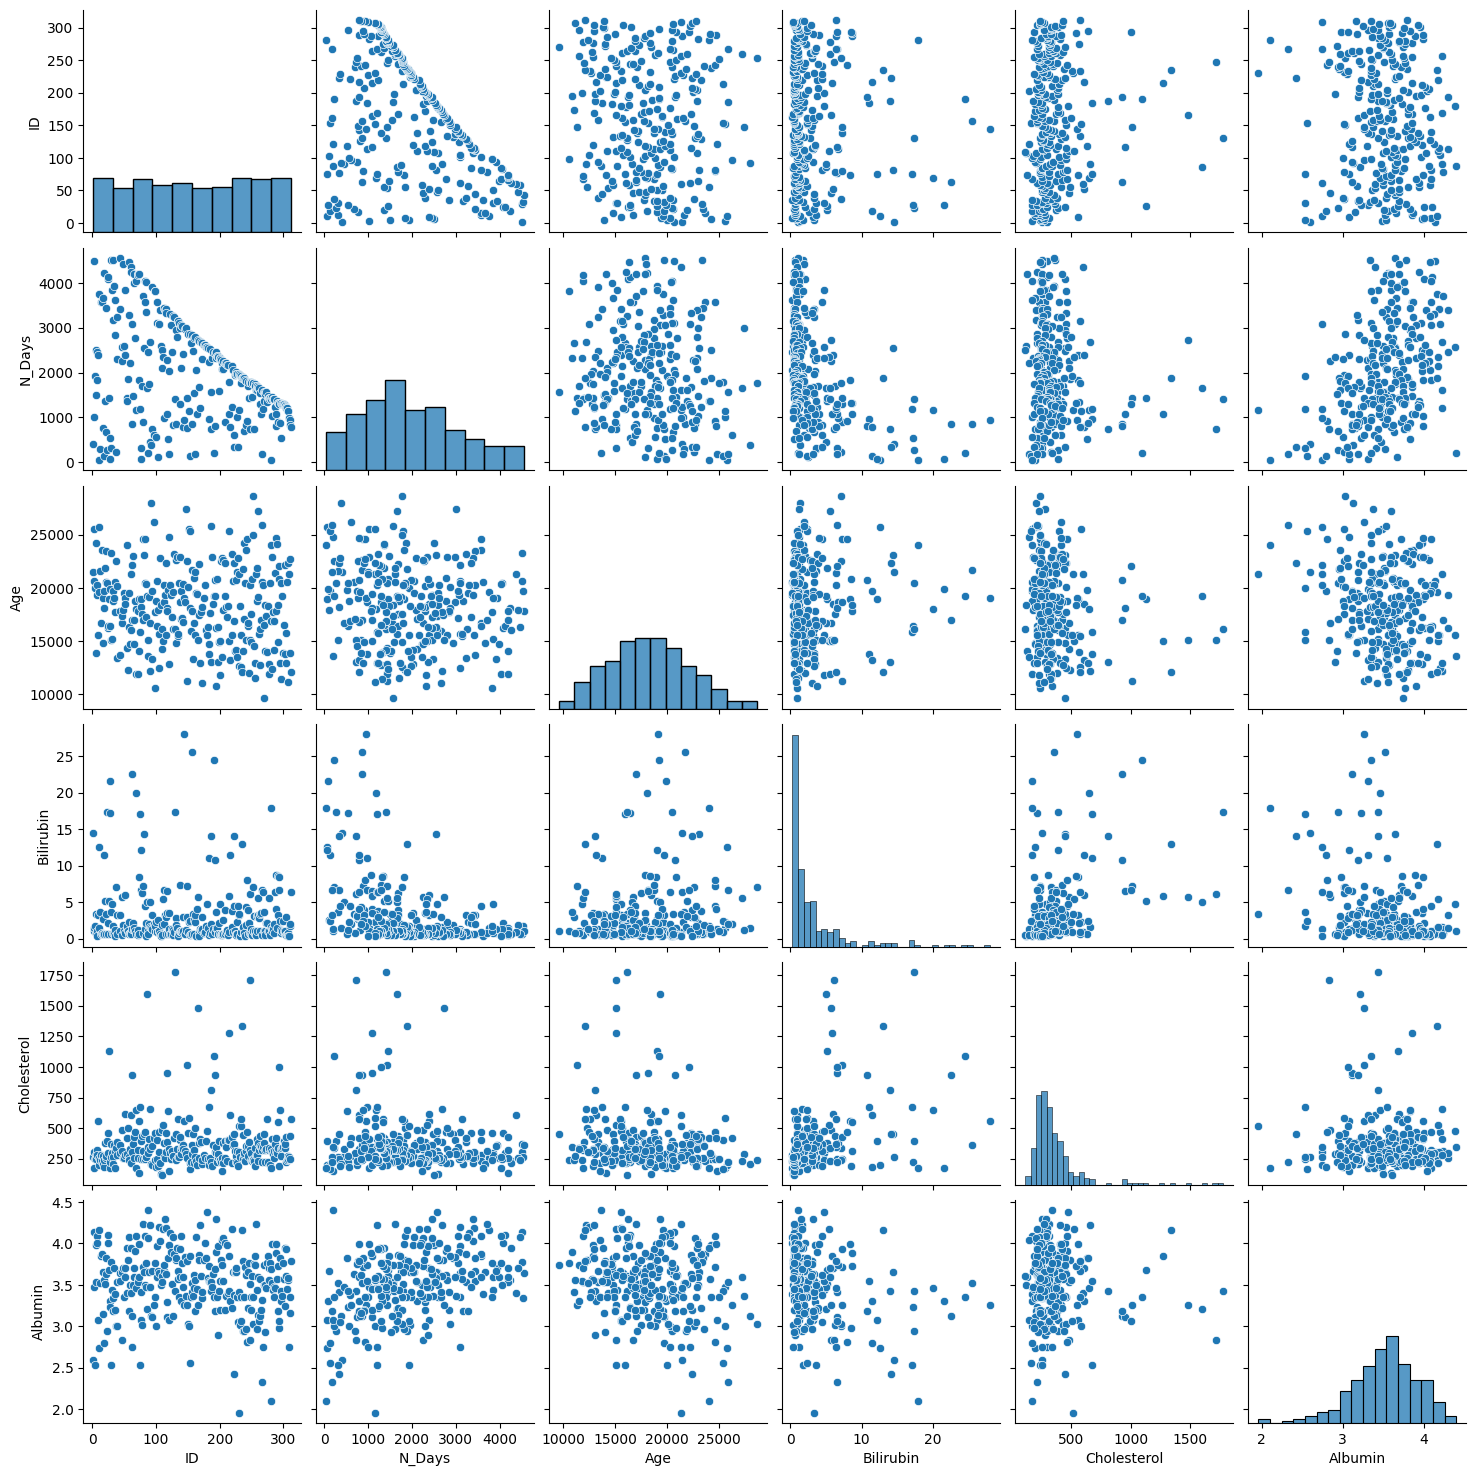

In [13]:
sample_cols = df_clean.columns[:6]

sns.pairplot(df_clean[sample_cols].dropna())

In [14]:
correlation_matrix = df_clean.corr()

correlation_matrix

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
ID,1.000000,-0.354305,0.037136,-0.062154,0.032897,-0.128924,-0.098663,-0.352856,-0.012097,-0.034100,-0.076699,-0.191930,-0.033757
N_Days,-0.354305,1.000000,-0.125934,-0.403953,-0.138236,0.430829,-0.364809,0.149269,-0.225492,-0.153000,0.151361,-0.111470,-0.366193
Age,0.037136,-0.125934,1.000000,0.002362,-0.157620,-0.182350,0.061549,-0.047247,-0.149869,0.022065,-0.148201,0.113760,0.189083
Bilirubin,-0.062154,-0.403953,0.002362,1.000000,0.397129,-0.314177,0.456918,0.116984,0.441730,0.436748,-0.013435,0.314894,0.200731
Cholesterol,0.032897,-0.138236,-0.157620,0.397129,1.000000,-0.069733,0.126115,0.149473,0.353246,0.276830,0.191710,-0.030811,0.011164
Albumin,-0.128924,0.430829,-0.182350,-0.314177,-0.069733,1.000000,-0.264771,-0.101456,-0.220047,-0.103417,0.158659,-0.200592,-0.305296
Copper,-0.098663,-0.364809,0.061549,0.456918,0.126115,-0.264771,1.000000,0.187357,0.293829,0.279852,-0.064403,0.218224,0.269400
Alk_Phos,-0.352856,0.149269,-0.047247,0.116984,0.149473,-0.101456,0.187357,1.000000,0.112217,0.180082,0.143733,0.089384,0.041273
SGOT,-0.012097,-0.225492,-0.149869,0.441730,0.353246,-0.220047,0.293829,0.112217,1.000000,0.126119,-0.120147,0.112174,0.164945
Tryglicerides,-0.034100,-0.153000,0.022065,0.436748,0.276830,-0.103417,0.279852,0.180082,0.126119,1.000000,0.103212,0.020122,0.123899


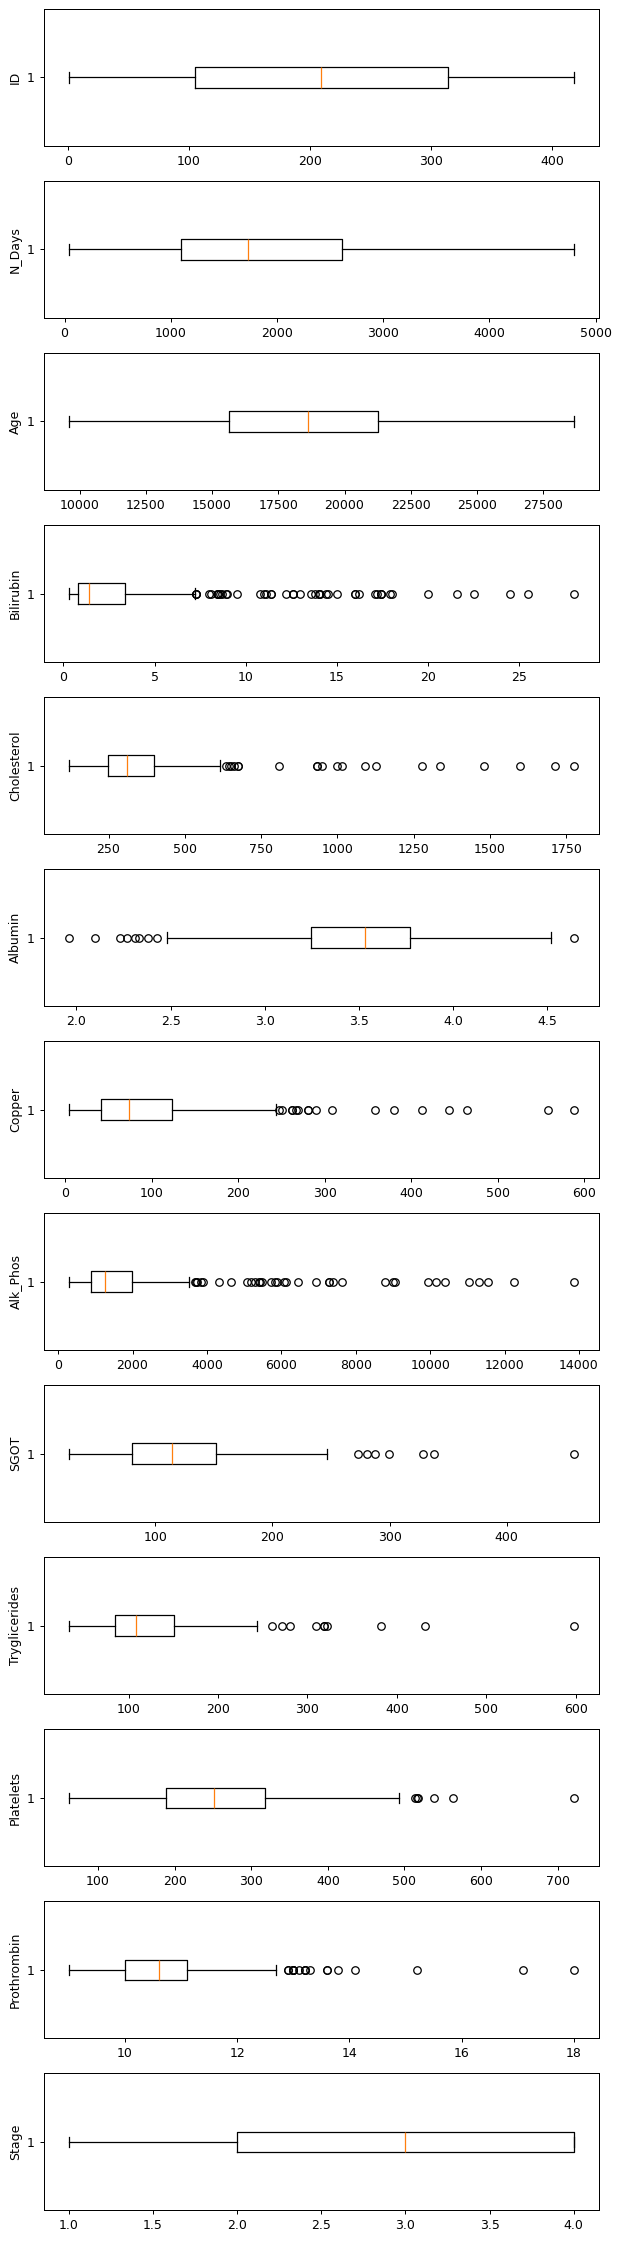

In [15]:
fig, axs = plt.subplots(len(df_clean.columns), 1, figsize=(7, 25), dpi=90)

for i, col in enumerate(df_clean.columns):
    axs[i].boxplot(df_clean[col].dropna(), vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

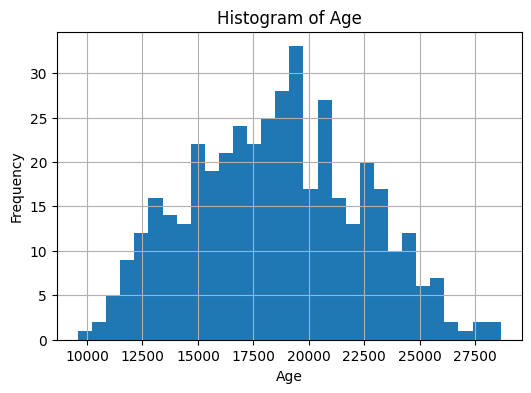

In [17]:
plt.figure(figsize=(6,4))

target_col = 'Age'  # Changed to a numeric column for histogram

df_clean[target_col].hist(bins=30)

plt.xlabel(target_col)
plt.ylabel('Frequency')
plt.title(f'Histogram of {target_col}')

plt.show()

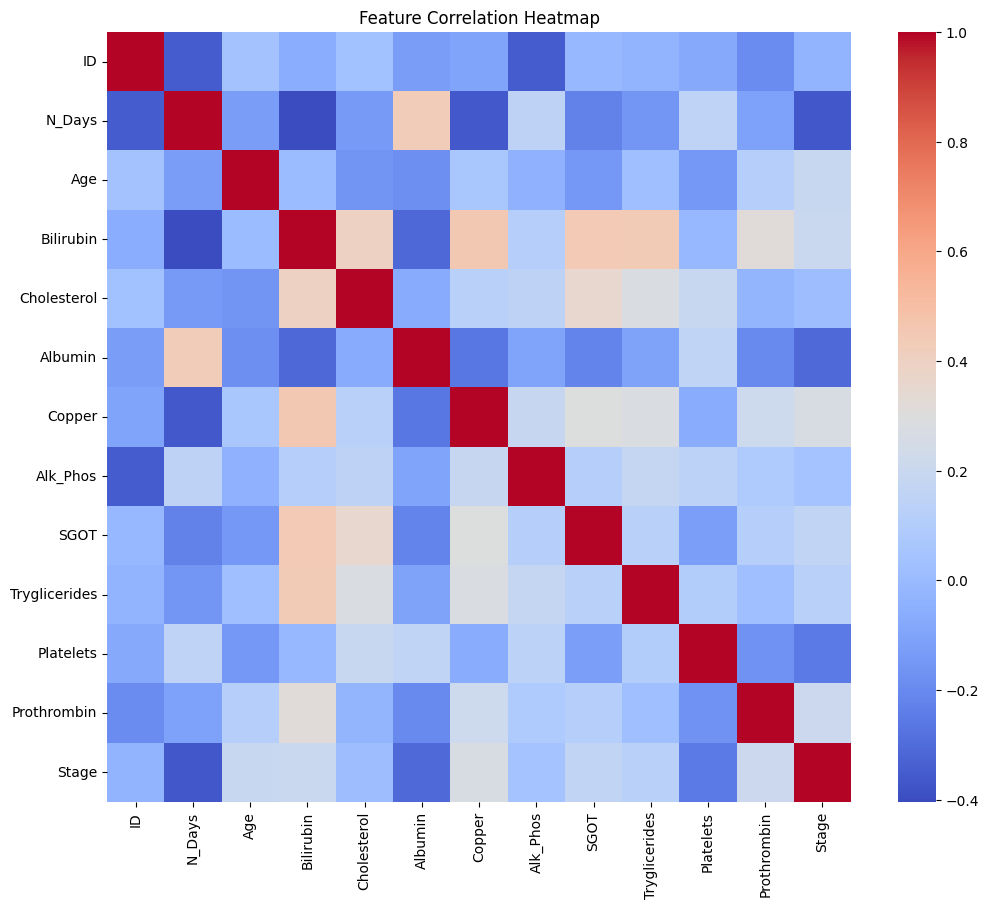

In [18]:
plt.figure(figsize=(12,10))

sns.heatmap(df_clean.corr(), cmap='coolwarm', annot=False)

plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (418, 12)
y shape: (418,)


In [20]:
corr_target = df_clean.corr()[target_col].sort_values(ascending=False)

corr_target

,Age
Age,1.000000
Stage,0.189083
Prothrombin,0.113760
Copper,0.061549
ID,0.037136
Tryglicerides,0.022065
Bilirubin,0.002362
Alk_Phos,-0.047247
N_Days,-0.125934
Platelets,-0.148201


In [21]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X.fillna(0))

X_minmax[:5]

array([[0.        , 0.07551536, 0.51263538, 0.14704225, 0.23880597,
        0.26530612, 0.12393236, 0.30169492, 0.28762542, 0.26352288,
        0.67777778, 1.        ],
       [0.00239808, 0.93794699, 0.02888087, 0.17014085, 0.81343284,
        0.09183673, 0.53344298, 0.24826681, 0.14715719, 0.30651872,
        0.58888889, 0.75      ],
       [0.00479616, 0.20424905, 0.03971119, 0.09915493, 0.56716418,
        0.35714286, 0.03722299, 0.21016949, 0.09197324, 0.20943135,
        0.66666667, 1.        ],
       [0.00719424, 0.39629785, 0.05415162, 0.13746479, 0.21641791,
        0.10884354, 0.44161184, 0.13259705, 0.15384615, 0.25381415,
        0.57222222, 1.        ],
       [0.00959233, 0.30774085, 0.11191336, 0.1571831 , 0.5858209 ,
        0.24319728, 0.04840432, 0.24745763, 0.12040134, 0.18862691,
        0.60555556, 0.75      ]])

In [22]:
print("Variance:\n", df_clean.var())

print("\nStandard Deviation:\n", df_clean.std())

Variance:
 ID               1.459517e+04
N_Days           1.220302e+06
Age              1.456067e+07
Bilirubin        1.942611e+01
Cholesterol      5.379827e+04
Albumin          1.806009e-01
Copper           7.329743e+03
Alk_Phos         4.581264e+06
SGOT             3.214836e+03
Tryglicerides    4.244345e+03
Platelets        9.667921e+03
Prothrombin      1.044485e+00
Stage            7.779983e-01
dtype: float64

Standard Deviation:
 ID                120.810458
N_Days           1104.672992
Age              3815.845055
Bilirubin           4.407506
Cholesterol       231.944545
Albumin             0.424972
Copper             85.613920
Alk_Phos         2140.388824
SGOT               56.699525
Tryglicerides      65.148639
Platelets          98.325585
Prothrombin         1.022000
Stage               0.882042
dtype: float64


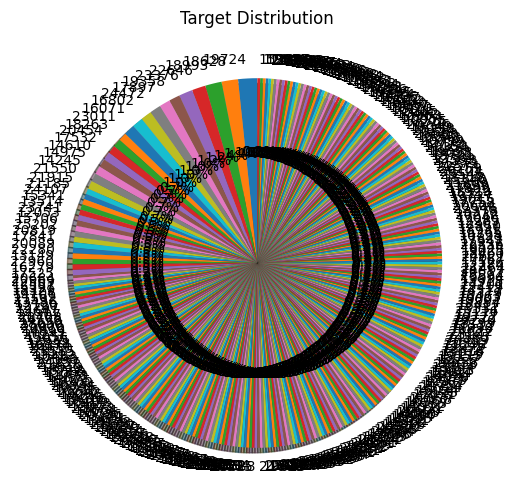

In [23]:
plt.figure(figsize=(6,6))

value_counts = df[target_col].value_counts()

plt.pie(
    value_counts,
    labels=value_counts.index,
    autopct='%.1f%%',
    shadow=True,
    startangle=90
)

plt.title("Target Distribution")
plt.show()